### RaschPy vector-by-items MFRM worked example

This notebook works through a sample Rasch analysis of a simulated data set (200 persons, 8 items with a maximum score of 5, all rated by 8 raters, no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

Under the items parameterisation, each rater has a separate severity for every item (rather than a single scalar severity as in the global model).

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

In [1]:
import raschpy as rp
import pandas as pd
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if the data is disconnected — i.e. there is no chain of persons and items linking every item to every other, the resulting item locations are not on a common scale, even though `calibrate()` will still run without error. Here we build a small, deliberately disconnected data set as an example: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.MFRM_Sim_Items(no_of_items=8, no_of_persons=40, no_of_facet_elements=4, max_score=5, seed=99)
responses_disconnected = sim_disconnected.responses.copy()
persons = responses_disconnected.index.get_level_values(1).unique()
group_a, group_b = persons[:20], persons[20:]
responses_disconnected.loc[(slice(None), group_a), responses_disconnected.columns[4:]] = float('nan')   # group A: only items 1-4
responses_disconnected.loc[(slice(None), group_b), responses_disconnected.columns[:4]] = float('nan')    # group B: only items 5-8

broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/mfrm.py:391: UserWarning: The data is split into 2 disconnected sub-networks. This will break un-smoothed calibrations. Isolated groupings: Sub-group 1 (size 4): ['Item_1', 'Item_2', 'Item_3', 'Item_4']; Sub-group 2 (size 4): ['Item_5', 'Item_6', 'Item_7', 'Item_8']
  self.connectivity_status = self.check_data_connectivity()
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_32782/1822966266.py:8: UserWarning: 
⚠️  CRITICAL DATA INTEGRITY WARNING: The response data is disconnected into 2 separate sub-networks.
Item location estimates will be problematic because there are no empirical comparisons spanning across these isolated groups, the item parameter estimates for each independent subset will separately sum to zero. This means items belonging to different subsets cannot be compared or calibrated onto a single scale.
  broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning


`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_mfrm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4'],
  ['Item_5', 'Item_6', 'Item_7', 'Item_8']],
 'directionally_isolated_items': []}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=42` makes the simulation fully reproducible — rerunning this notebook will always generate the same data set. 12 items, 8 raters, 200 persons, no missing data.

In [4]:
sim = rp.MFRM_Sim_Items(no_of_items=12, no_of_persons=200, no_of_facet_elements=8, max_score=5, missing=0, seed=42)
sim.responses.to_csv('mfrm_items_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_mfrm_single()` to load and validate it. Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_mfrm_single('mfrm_items_scores.csv', max_score=5)

Check the data - view the first two lines

In [6]:
data.head(2)

Item_1  Item_2  Item_3  Item_4  Item_5  Item_6  Item_7  \
Rater   Person                                                             
Rater_1 Person_1     3.0     4.0     2.0     1.0     3.0     4.0     3.0   
        Person_2     3.0     0.0     2.0     0.0     0.0     3.0     0.0   

                  Item_8  Item_9  Item_10  Item_11  Item_12  
Rater   Person                                               
Rater_1 Person_1     2.0     4.0      2.0      3.0      1.0  
        Person_2     2.0     2.0      2.0      0.0      1.0

Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater,Person,,,,,,,,,,,,


Create an MFRM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `mfrm.generating`, which lets us check parameter recovery further down. If you're analysing your own data, pass a DataFrame instead (e.g. `rp.MFRM(data)`).

In [8]:
mfrm = rp.MFRM(sim)

Calibrate under the items parameterisation (a separate severity per rater x item combination). The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
mfrm.calibrate_items()

CPU times: user 4.31 ms, sys: 354 μs, total: 4.66 ms
Wall time: 4.48 ms


Check the item location estimates - view the first two items

In [10]:
mfrm.items

Item_1    -0.968331
Item_2    -0.475132
Item_3    -0.696890
Item_4     0.488070
Item_5    -0.713213
Item_6     0.098240
Item_7     0.588036
Item_8     0.310390
Item_9    -0.568405
Item_10    0.775870
Item_11    0.549425
Item_12    0.611940
dtype: float64

Since this is simulated data, we know the true generating item locations (`mfrm.generating.items`) and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) — the closer the points hug the identity line, the better the recovery. Also displays the Pearson correlation, SD ratio, regression coefficient and RMSE:

In [11]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:              {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                              {round(np.sqrt(((x - y) ** 2).mean()), 3)}')


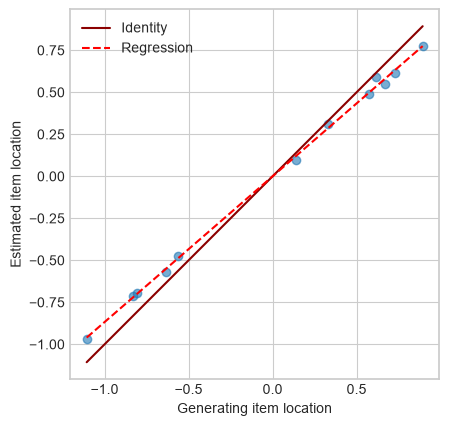

item location Pearson correlation:              0.999
item location SD ratio (estimated / generating): 0.868
item location regression coefficient:            0.868
item location RMSE:                              0.096


In [12]:
recovery_plot(mfrm.generating.items, mfrm.items, 'item location', 'my_mfrm_items_item_recovery.png')

Generate a table of item statistics (and check run time), and save to file

In [13]:
%%time
mfrm.item_stats_df_items(full=True)
mfrm.item_stats_items.to_csv('mfrm_items_item_stats.csv')

CPU times: user 16.6 s, sys: 76.1 ms, total: 16.6 s
Wall time: 16.6 s


Check the item statistics table

In [14]:
mfrm.item_stats_items

,Estimate,SE,2.5%,97.5%,Count,Facility,Infit MS,Infit Z,Outfit MS,Outfit Z,PM corr,Exp PM corr
Item_1,-0.968,0.042,-1.048,-0.888,1600,0.690,0.911,-2.576,0.930,-2.014,0.684,0.670
Item_2,-0.475,0.038,-0.553,-0.403,1600,0.607,0.939,-1.742,0.944,-1.601,0.705,0.689
Item_3,-0.697,0.037,-0.771,-0.623,1600,0.649,0.897,-3.018,0.948,-1.493,0.705,0.688
Item_4,0.488,0.035,0.420,0.559,1600,0.415,0.851,-4.431,0.849,-4.494,0.746,0.709
Item_5,-0.713,0.036,-0.780,-0.644,1600,0.651,0.918,-2.373,0.921,-2.278,0.712,0.689
Item_6,0.098,0.036,0.031,0.167,1600,0.483,0.886,-3.328,0.884,-3.403,0.740,0.717
Item_7,0.588,0.035,0.519,0.650,1600,0.404,0.953,-1.348,0.982,-0.499,0.748,0.720
Item_8,0.310,0.036,0.242,0.381,1600,0.452,0.845,-4.624,0.873,-3.749,0.762,0.732
Item_9,-0.568,0.034,-0.639,-0.500,1600,0.622,0.823,-5.323,0.834,-4.960,0.752,0.704
Item_10,0.776,0.038,0.707,0.851,1600,0.352,0.902,-2.862,0.906,-2.729,0.743,0.713


Generate a table of threshold statistics (and check run time), and save to file

In [15]:
%%time
mfrm.threshold_stats_df_items(full=True)
mfrm.threshold_stats_items.to_csv('mfrm_items_threshold_stats.csv')

CPU times: user 72 ms, sys: 1.59 ms, total: 73.6 ms
Wall time: 73.5 ms


Check the threshold statistics table

In [16]:
mfrm.threshold_stats_items

,Estimate,SE,2.5%,97.5%,Infit MS,Infit Z,Outfit MS,Outfit Z,Discrim,PM corr,Exp PM corr
Threshold 1,-0.937,0.044,-1.013,-0.841,1.010,0.905,1.006,0.416,0.972,0.411,0.370
Threshold 2,-0.786,0.037,-0.848,-0.703,0.972,-2.935,0.965,-2.822,1.123,0.388,0.343
Threshold 3,-0.776,0.030,-0.822,-0.706,0.979,-2.075,0.969,-2.086,1.059,0.490,0.422
Threshold 4,0.949,0.031,0.884,0.999,0.954,-5.288,0.937,-5.311,1.151,0.594,0.519
Threshold 5,1.550,0.046,1.450,1.624,0.960,-3.716,0.967,-2.177,1.117,0.575,0.532


And the same recovery check for thresholds, against `mfrm.generating.thresholds`:

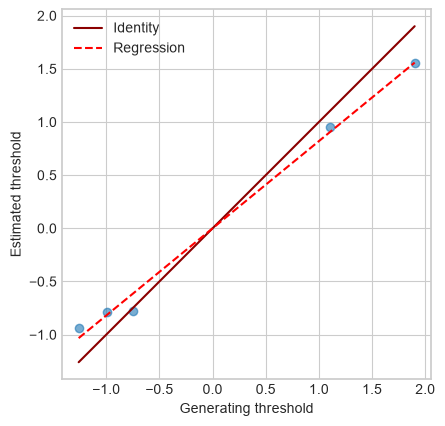

threshold Pearson correlation:              0.996
threshold SD ratio (estimated / generating): 0.823
threshold regression coefficient:            0.82
threshold RMSE:                              0.244


In [17]:
recovery_plot(mfrm.generating.thresholds, mfrm.thresholds, 'threshold', 'my_mfrm_items_threshold_recovery.png')

Generate a table of rater statistics (and check run time), and save to file

In [18]:
%%time
mfrm.rater_stats_df_items()
mfrm.rater_stats_items.to_csv('mfrm_items_rater_stats.csv')

CPU times: user 32.8 ms, sys: 609 μs, total: 33.4 ms
Wall time: 33.4 ms


Check the rater statistics table

In [19]:
mfrm.rater_stats_items

Item_1          Item_2          Item_3          Item_4         \
        Estimate     SE Estimate     SE Estimate     SE Estimate     SE   
Rater_1    0.149  0.117    0.405  0.111    0.468  0.113   -0.059  0.103   
Rater_2    0.309  0.122    0.788  0.112    0.276  0.109    0.118  0.105   
Rater_3    0.800  0.128    0.126  0.105   -0.488  0.124   -0.031  0.107   
Rater_4   -0.229  0.109   -0.844  0.113    0.208  0.103   -0.670  0.120   
Rater_5   -0.796  0.127   -0.680  0.116   -0.572  0.121   -0.736  0.124   
Rater_6   -0.248  0.109   -0.209  0.112   -0.629  0.108    0.491  0.117   
Rater_7   -0.297  0.106    0.447  0.110    0.568  0.116    1.010  0.135   
Rater_8    0.312  0.111   -0.033  0.113    0.169  0.105   -0.123  0.108   

          Item_5         ... Item_9  Item_10         Item_11         Item_12  \
        Estimate     SE  ...     SE Estimate     SE Estimate     SE Estimate   
Rater_1    0.498  0.118  ...  0.108   -0.575  0.118    0.063  0.104    0.781   
Rater_2    0.364  0.119  ...  0.113   -0.448  0.107    0.133  0.110   -0.060   
Rater_3   -0.310  0.113  ...  0.109   -0.216  0.109    0.274  0.107    0.418   
Rater_4    0.453  0.116  ...  0.113   -0.432  0.115   -0.551  0.111   -0.758   
Rater_5   -0.214  0.108  ...  0.106    0.691  0.132    0.660  0.127   -1.106   
Rater_6   -0.216  0.110  ...  0.108    0.703  0.141   -0.547  0.117    0.514   
Rater_7    0.277  0.105  ...  0.109    0.361  0.115    0.172  0.108    0.551   
Rater_8   -0.852  0.136  ...  0.108   -0.084  0.115   -0.204  0.114   -0.340   

               Overall statistics                     
            SE              Count Infit MS Outfit MS  
Rater_1  0.133             2400.0    0.905     0.909  
Rater_2  0.116             2400.0    0.878     0.879  
Rater_3  0.112             2400.0    0.889     0.942  
Rater_4  0.120             2400.0    0.884     0.911  
Rater_5  0.119             2400.0    0.888     0.900  
Rater_6  0.122             2400.0    0.857     0.869  
Rater_7  0.117             2400.0    0.933     0.926  
Rater_8  0.105             2400.0    0.884     0.902  

[8 rows x 27 columns]

And the same recovery check for rater x item severities, against `mfrm.generating.facet_effects`. Since these are per rater x item, we flatten with `.unstack()` first:

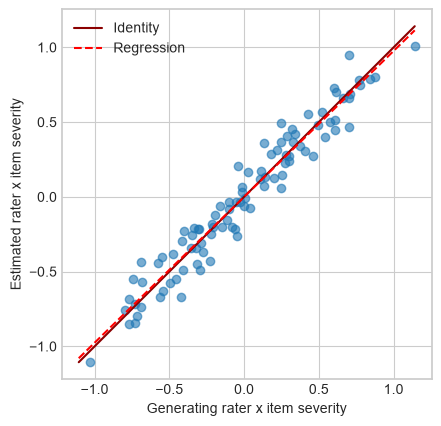

rater x item severity Pearson correlation:              0.971
rater x item severity SD ratio (estimated / generating): 1.006
rater x item severity regression coefficient:            0.976
rater x item severity RMSE:                              0.114


In [20]:
orig_severities = mfrm.generating.facet_effects.unstack()
est_severities = mfrm.raters_items.unstack()
recovery_plot(orig_severities, est_severities, 'rater x item severity', 'my_mfrm_items_rater_recovery.png')

Generate a table of person statistics (and check run time), and save to file

In [21]:
%%time
mfrm.person_stats_df_items(full=True)
mfrm.person_stats_items.to_csv('mfrm_items_person_stats.csv')

CPU times: user 11 ms, sys: 511 μs, total: 11.5 ms
Wall time: 11.6 ms


Check the person statistics table - view the first ten persons with `.head(10)`

In [22]:
mfrm.person_stats_items.head(10)

,Estimate,CSEM,RSEM,Score,Max score,p,Infit MS,Outfit MS,Infit Z,Outfit Z
Person_1,0.501,0.102,0.097,304,480,0.633,0.910,0.927,-0.595,-0.479
Person_2,-1.170,0.101,0.086,126,480,0.262,0.725,0.666,-2.111,-2.203
Person_3,0.926,0.110,0.110,342,480,0.712,1.006,0.994,0.089,0.008
Person_4,1.127,0.114,0.118,358,480,0.746,1.062,1.029,0.451,0.246
Person_5,-2.431,0.155,0.143,37,480,0.077,0.849,0.759,-0.648,-0.779
Person_6,-1.606,0.112,0.104,87,480,0.181,0.855,0.873,-0.920,-0.585
Person_7,0.191,0.098,0.084,273,480,0.569,0.735,0.763,-2.050,-1.788
Person_8,-0.387,0.095,0.099,210,480,0.438,1.101,1.101,0.777,0.749
Person_9,0.201,0.098,0.098,274,480,0.571,0.997,1.013,0.022,0.136
Person_10,-1.231,0.102,0.110,120,480,0.250,1.162,1.071,1.126,0.463


And the same recovery check for person locations, against `mfrm.generating.persons`:

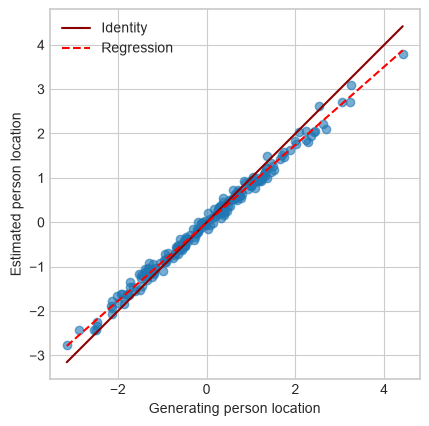

person location Pearson correlation:              0.996
person location SD ratio (estimated / generating): 0.884
person location regression coefficient:            0.88
person location RMSE:                              0.192


In [23]:
recovery_plot(mfrm.generating.persons, mfrm.persons_items, 'person location', 'my_mfrm_items_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [24]:
%%time
mfrm.test_stats_df_items()
mfrm.test_stats_items.to_csv('mfrm_items_test_stats.csv')

CPU times: user 2.21 ms, sys: 704 μs, total: 2.91 ms
Wall time: 2.81 ms


Check the test statistics table

In [25]:
mfrm.test_stats_items

,Items,Persons
Mean,-0.000,-0.013
SD,0.636,1.169
Separation ratio,16.887,11.039
Strata,22.849,15.052
Reliability,0.997,0.992


Run a residual correlation analysis for items (and check run time), and save relevant output to file

In [26]:
%%time
mfrm.item_res_corr_analysis_items()
mfrm.item_residual_correlations_items.to_csv('mfrm_items_item_residual_correlations.csv')
mfrm.item_loadings_items.to_csv('mfrm_items_item_loadings.csv')

CPU times: user 5.88 ms, sys: 1.62 ms, total: 7.51 ms
Wall time: 8.38 ms


View the table of pairwise standard residual correlations (pairwise local item independence check)

In [27]:
round(mfrm.item_residual_correlations_items, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Item_1,1.000,-0.035,-0.029,0.044,-0.010,-0.000,-0.052,-0.012,-0.014,0.006,0.010,-0.029
Item_2,-0.035,1.000,-0.033,-0.015,-0.039,-0.005,0.022,-0.030,0.058,-0.017,-0.026,-0.019
Item_3,-0.029,-0.033,1.000,0.001,-0.001,-0.012,-0.014,0.020,0.032,0.002,-0.002,-0.008
Item_4,0.044,-0.015,0.001,1.000,-0.008,-0.041,0.050,-0.011,0.012,0.023,-0.008,-0.032
Item_5,-0.010,-0.039,-0.001,-0.008,1.000,-0.040,0.017,0.029,0.008,-0.006,-0.036,-0.024
Item_6,-0.000,-0.005,-0.012,-0.041,-0.040,1.000,-0.033,0.001,-0.022,-0.002,0.027,-0.013
Item_7,-0.052,0.022,-0.014,0.050,0.017,-0.033,1.000,-0.023,0.013,0.032,-0.004,-0.030
Item_8,-0.012,-0.030,0.020,-0.011,0.029,0.001,-0.023,1.000,-0.025,-0.039,0.000,0.006
Item_9,-0.014,0.058,0.032,0.012,0.008,-0.022,0.013,-0.025,1.000,-0.029,0.025,-0.022
Item_10,0.006,-0.017,0.002,0.023,-0.006,-0.002,0.032,-0.039,-0.029,1.000,-0.061,0.011


View the item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [28]:
round(mfrm.item_loadings_items['PC 1'], 3)

Item_1    -0.042
Item_2     0.079
Item_3    -0.029
Item_4     0.117
Item_5     0.041
Item_6    -0.132
Item_7     0.165
Item_8    -0.109
Item_9     0.053
Item_10    0.100
Item_11   -0.125
Item_12   -0.088
Name: PC 1, dtype: float64

Run a residual correlation analysis for raters (and check run time), and save relevant output to file

In [29]:
%%time
mfrm.rater_res_corr_analysis_items()
mfrm.rater_residual_correlations_items.to_csv('mfrm_items_rater_residual_correlations.csv')
mfrm.rater_loadings_items.to_csv('mfrm_items_rater_loadings.csv')

CPU times: user 8.71 ms, sys: 600 μs, total: 9.31 ms
Wall time: 9.25 ms


View the table of pairwise standard residual correlations (pairwise local rater independence check)

In [30]:
round(mfrm.rater_residual_correlations_items, 3)

,Rater_1,Rater_2,Rater_3,Rater_4,Rater_5,Rater_6,Rater_7,Rater_8
Rater_1,1.000,-0.030,-0.007,-0.013,-0.019,-0.008,0.016,0.009
Rater_2,-0.030,1.000,0.017,-0.042,0.015,-0.025,-0.021,-0.015
Rater_3,-0.007,0.017,1.000,-0.042,-0.004,-0.002,-0.029,-0.003
Rater_4,-0.013,-0.042,-0.042,1.000,-0.003,0.000,0.019,-0.015
Rater_5,-0.019,0.015,-0.004,-0.003,1.000,-0.017,0.010,-0.029
Rater_6,-0.008,-0.025,-0.002,0.000,-0.017,1.000,-0.009,-0.001
Rater_7,0.016,-0.021,-0.029,0.019,0.010,-0.009,1.000,-0.030
Rater_8,0.009,-0.015,-0.003,-0.015,-0.029,-0.001,-0.030,1.000


View the rater loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [31]:
round(mfrm.rater_loadings_items['PC 1'], 3)

Rater_1   -0.079
Rater_2    0.240
Rater_3    0.180
Rater_4   -0.208
Rater_5    0.084
Rater_6   -0.075
Rater_7   -0.111
Rater_8   -0.028
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) curve for Item 2, with observed category means plotted and the central item location marked

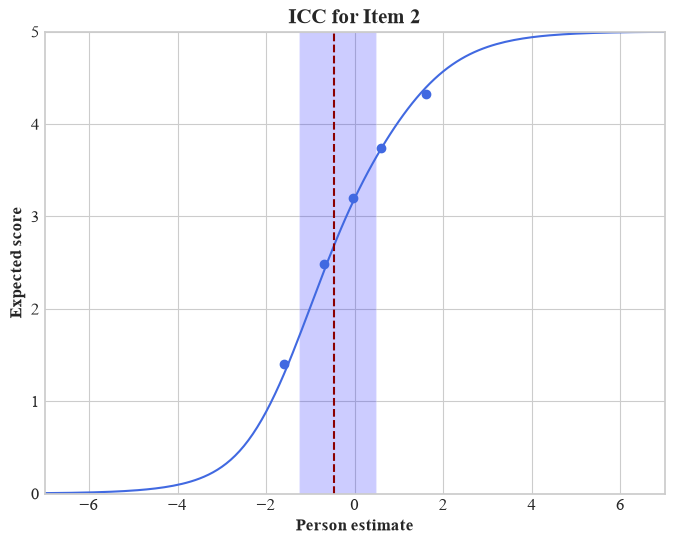

In [32]:
mfrm.icc_items('Item_2', title='ICC for Item 2', obs=True, central_location=True, cat_highlight=3, xmin=-7, xmax=7, filename='my_mfrm_items_icc')

Produce a set of category response curves for Item 2, with category 1 highlighted and the thresholds marked

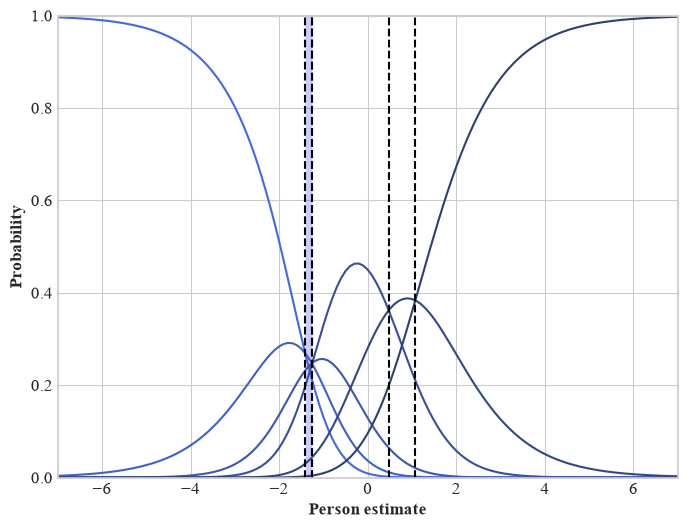

In [33]:
mfrm.crcs_items('Item_2', thresh_lines=True, cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_items_crcs')

Produce a set of threshold characteristic curves for Item 2, with observed category means plotted for threshold 3, category 1 highlighted and the thresholds marked

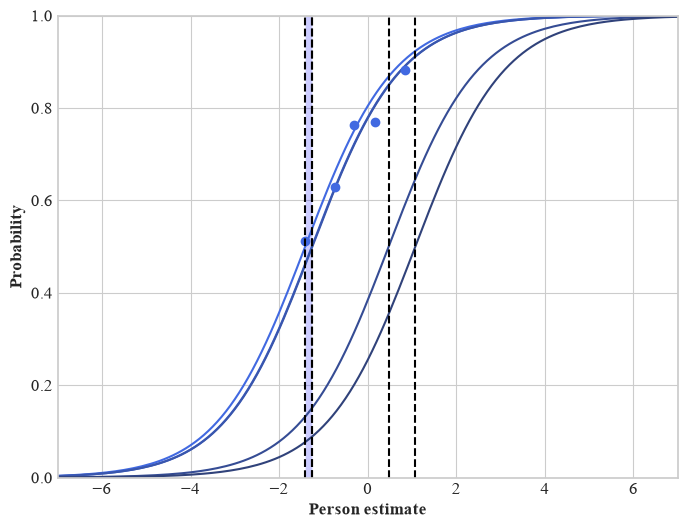

In [34]:
mfrm.threshold_ccs_items('Item_2', thresh_lines=True, obs=[3], cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_items_threshold_ccs')

Produce an item information function curve for Item 2

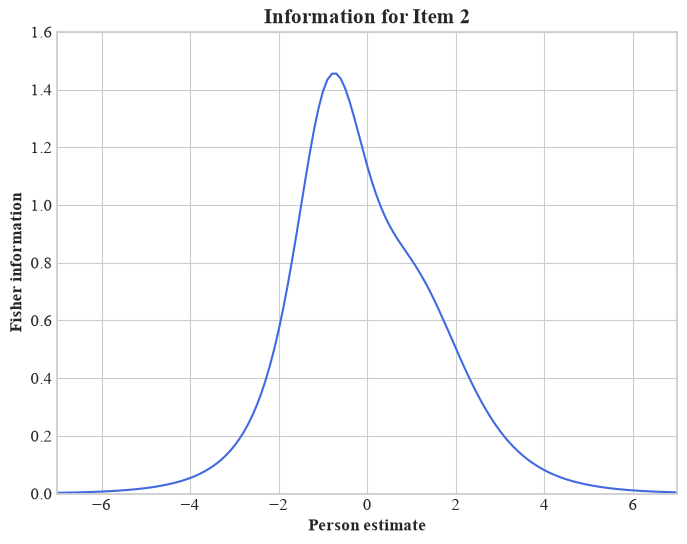

In [35]:
mfrm.iic_items('Item_2', title='Information for Item 2', xmin=-7, xmax=7, filename='my_mfrm_items_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 150 and 250 (aggregated across all raters) plotted.

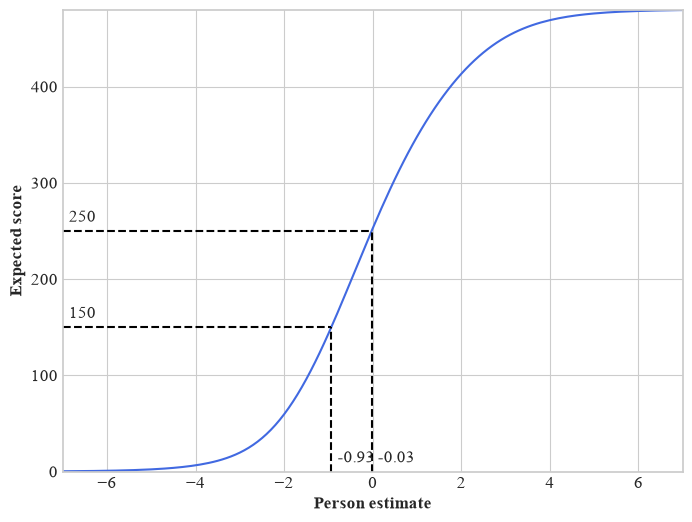

In [36]:
mfrm.tcc_items(score_lines=[150, 250], score_labels=True, xmin=-7, xmax=7, filename='my_mfrm_items_tcc')

Produce a test information curve

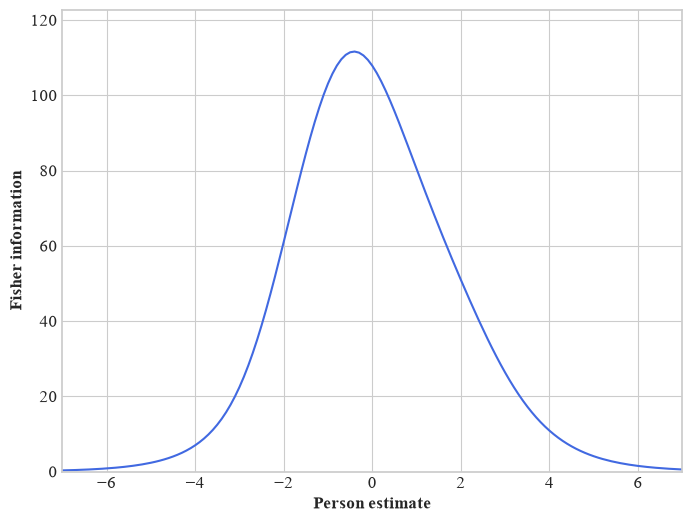

In [37]:
mfrm.test_info_items(xmin=-7, xmax=7, filename='my_mfrm_items_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

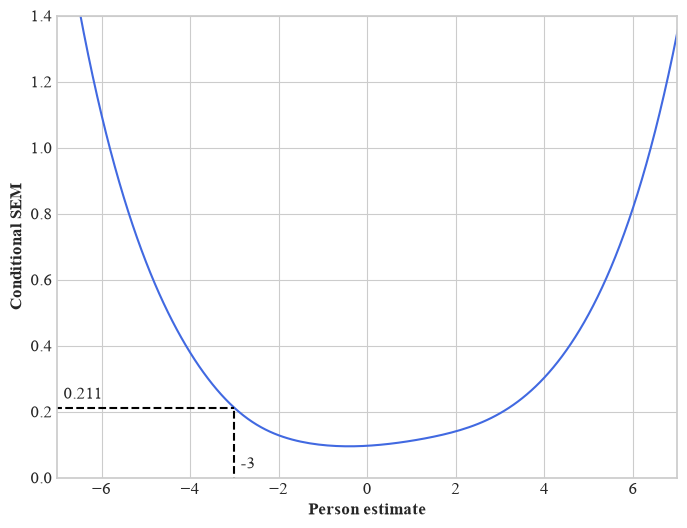

In [38]:
mfrm.test_csem_items(point_csem_lines=[-3], point_csem_labels=True, ymax=1.4, xmin=-7, xmax=7, filename='my_mfrm_items_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

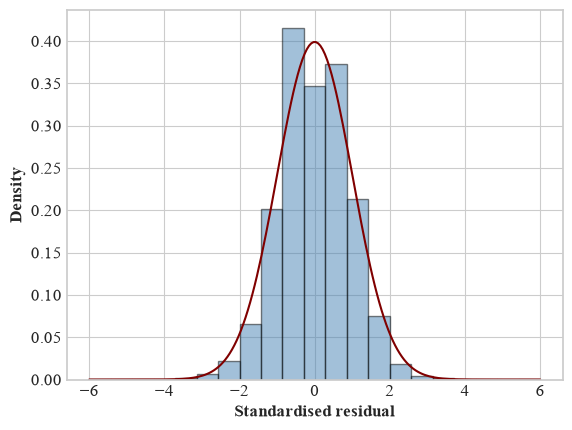

In [39]:
mfrm.std_residuals_plot_items(bin_width=0.6, normal=True, filename='my_mfrm_items_std_residuals_plot')

Now run an anchored analysis, anchoring to the mean severity of Raters 1-4 (e.g. a set of 'gold standard' raters).

In [40]:
%%time
anchors = ['Rater_1', 'Rater_2', 'Rater_3', 'Rater_4']
mfrm.calibrate_items_anchor(anchors)

CPU times: user 1.05 ms, sys: 295 μs, total: 1.34 ms
Wall time: 1.16 ms


Check the anchored item locations against the unanchored ones.

In [41]:
item_check = pd.DataFrame({'Unanchored': mfrm.items,
                           'Anchored': mfrm.anchor_items_items})
round(item_check, 3)

,Unanchored,Anchored
Item_1,-0.968,-0.743
Item_2,-0.475,-0.389
Item_3,-0.697,-0.613
Item_4,0.488,0.295
Item_5,-0.713,-0.494
Item_6,0.098,-0.104
Item_7,0.588,0.603
Item_8,0.310,0.483
Item_9,-0.568,-0.535
Item_10,0.776,0.326


Check the anchored rater x item severities against the unanchored ones (two separate dataframes)

In [42]:
round(mfrm.raters_items, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater_1,0.149,0.405,0.468,-0.059,0.498,-0.439,0.289,-0.072,-0.254,-0.575,0.063,0.781
Rater_2,0.309,0.788,0.276,0.118,0.364,-0.714,-0.668,0.343,0.750,-0.448,0.133,-0.060
Rater_3,0.800,0.126,-0.488,-0.031,-0.310,0.481,0.948,-0.182,-0.032,-0.216,0.274,0.418
Rater_4,-0.229,-0.844,0.208,-0.670,0.453,-0.007,-0.381,0.729,-0.200,-0.432,-0.551,-0.758
Rater_5,-0.796,-0.680,-0.572,-0.736,-0.214,0.400,-0.260,-0.488,0.369,0.691,0.660,-1.106
Rater_6,-0.248,-0.209,-0.629,0.491,-0.216,-0.442,-0.203,-0.155,-0.340,0.703,-0.547,0.514
Rater_7,-0.297,0.447,0.568,1.010,0.277,0.661,0.242,0.224,-0.369,0.361,0.172,0.551
Rater_8,0.312,-0.033,0.169,-0.123,-0.852,0.060,0.033,-0.400,0.076,-0.084,-0.204,-0.340


In [43]:
round(mfrm.anchor_raters_items, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater_1,-0.108,0.286,0.352,0.102,0.246,-0.269,0.242,-0.276,-0.320,-0.157,0.083,0.685
Rater_2,0.052,0.669,0.160,0.279,0.113,-0.544,-0.715,0.139,0.684,-0.030,0.154,-0.155
Rater_3,0.543,0.007,-0.604,0.129,-0.561,0.651,0.901,-0.386,-0.098,0.202,0.294,0.323
Rater_4,-0.486,-0.963,0.092,-0.510,0.202,0.163,-0.428,0.524,-0.266,-0.014,-0.531,-0.853
Rater_5,-1.054,-0.799,-0.688,-0.575,-0.466,0.570,-0.307,-0.693,0.303,1.109,0.680,-1.201
Rater_6,-0.505,-0.328,-0.745,0.652,-0.467,-0.273,-0.250,-0.359,-0.406,1.121,-0.527,0.419
Rater_7,-0.554,0.328,0.452,1.170,0.026,0.830,0.195,0.019,-0.435,0.779,0.192,0.456
Rater_8,0.055,-0.152,0.053,0.037,-1.104,0.229,-0.014,-0.605,0.010,0.334,-0.183,-0.435
